# CyberShield

## Feature Engineering and Feature Selection

This notebook performs feature engineering and feature selection on the preprocessed UNSW-NB15 dataset. The objective is to prepare an optimized feature set for machine learning models used in cyber threat detection and protection.

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

## Load the Processed Dataset

In [2]:
data = pd.read_csv("../output/processed_dataset.csv")

print("Dataset Shape:", data.shape)

data.head()

Dataset Shape: (145222, 36)


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label,attack_cat
0,-0.237501,0.106283,-0.671545,0.139017,-0.144480,-0.191702,-0.061763,-0.129779,-0.242915,-0.183584,...,-0.187214,-0.052332,-0.270001,-0.156656,-0.127731,-0.127711,-0.324106,-0.064626,0,6
1,-0.138246,0.106283,-0.671545,0.139017,-0.099670,0.041842,-0.059690,0.089099,-0.242862,-0.183615,...,-0.187214,-0.052332,-0.270001,-0.156656,-0.127731,-0.127711,-0.324106,-0.064626,0,6
2,0.044557,0.106283,-0.671545,0.139017,-0.133277,-0.109275,-0.061301,-0.061702,-0.243648,-0.183651,...,-0.187214,-0.052332,-0.270001,-0.156656,-0.127731,-0.127711,-0.324106,-0.064626,0,6
3,0.055547,0.106283,0.409479,0.139017,-0.110872,-0.136750,-0.060151,-0.126651,-0.243655,-0.183645,...,-0.187214,-0.052332,-0.270001,-0.156656,7.646503,7.629053,-0.324106,-0.064626,0,6
4,-0.175897,0.106283,-0.671545,0.139017,-0.122075,-0.177964,-0.060561,-0.129277,-0.243413,-0.183614,...,-0.187214,-0.052332,0.078134,-0.156656,-0.127731,-0.127711,-0.324106,-0.064626,0,6


## Verify Dataset Information

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145222 entries, 0 to 145221
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                145222 non-null  float64
 1   proto              145222 non-null  float64
 2   service            145222 non-null  float64
 3   state              145222 non-null  float64
 4   spkts              145222 non-null  float64
 5   dpkts              145222 non-null  float64
 6   sbytes             145222 non-null  float64
 7   dbytes             145222 non-null  float64
 8   rate               145222 non-null  float64
 9   sload              145222 non-null  float64
 10  dload              145222 non-null  float64
 11  sloss              145222 non-null  float64
 12  dloss              145222 non-null  float64
 13  sinpkt             145222 non-null  float64
 14  dinpkt             145222 non-null  float64
 15  sjit               145222 non-null  float64
 16  dj

## Check Missing Values

In [4]:
data.isnull().sum()

dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
label                0
attack_cat           0
dtype: int64

## Check Duplicate Records

In [5]:
data.duplicated().sum()

np.int64(0)

## Display Dataset Columns

In [6]:
list(data.columns)

['dur',
 'proto',
 'service',
 'state',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'sload',
 'dload',
 'sloss',
 'dloss',
 'sinpkt',
 'dinpkt',
 'sjit',
 'djit',
 'swin',
 'stcpb',
 'dtcpb',
 'dwin',
 'tcprtt',
 'synack',
 'ackdat',
 'smean',
 'dmean',
 'trans_depth',
 'response_body_len',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'is_ftp_login',
 'ct_ftp_cmd',
 'ct_flw_http_mthd',
 'is_sm_ips_ports',
 'label',
 'attack_cat']

# Feature Engineering

Feature engineering is the process of creating meaningful features that improve model performance. In this project, additional security-related features will be generated to support the CyberShield protection engine.

## Encode Categorical Features

In [7]:
from sklearn.preprocessing import LabelEncoder

data_fe = data.copy()

encoder = LabelEncoder()

categorical_columns = ['proto', 'service', 'state', 'attack_cat']

for col in categorical_columns:
    data_fe[col] = encoder.fit_transform(data_fe[col])

data_fe.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label,attack_cat
0,-0.237501,113,0,4,-0.144480,-0.191702,-0.061763,-0.129779,-0.242915,-0.183584,...,-0.187214,-0.052332,-0.270001,-0.156656,-0.127731,-0.127711,-0.324106,-0.064626,0,6
1,-0.138246,113,0,4,-0.099670,0.041842,-0.059690,0.089099,-0.242862,-0.183615,...,-0.187214,-0.052332,-0.270001,-0.156656,-0.127731,-0.127711,-0.324106,-0.064626,0,6
2,0.044557,113,0,4,-0.133277,-0.109275,-0.061301,-0.061702,-0.243648,-0.183651,...,-0.187214,-0.052332,-0.270001,-0.156656,-0.127731,-0.127711,-0.324106,-0.064626,0,6
3,0.055547,113,3,4,-0.110872,-0.136750,-0.060151,-0.126651,-0.243655,-0.183645,...,-0.187214,-0.052332,-0.270001,-0.156656,7.646503,7.629053,-0.324106,-0.064626,0,6
4,-0.175897,113,0,4,-0.122075,-0.177964,-0.060561,-0.129277,-0.243413,-0.183614,...,-0.187214,-0.052332,0.078134,-0.156656,-0.127731,-0.127711,-0.324106,-0.064626,0,6


## Prepare Features and Target

In [8]:
X = data_fe.drop(['label', 'attack_cat'], axis=1)

y = data_fe['label']

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (145222, 34)
Target Shape : (145222,)


## Feature Importance using Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
23,ackdat,0.093989
22,synack,0.079521
10,dload,0.077850
21,tcprtt,0.072696
25,dmean,0.056583
8,rate,0.054557
6,sbytes,0.052953
7,dbytes,0.049060
24,smean,0.048598
14,dinpkt,0.048580


## Visualize Feature Importance

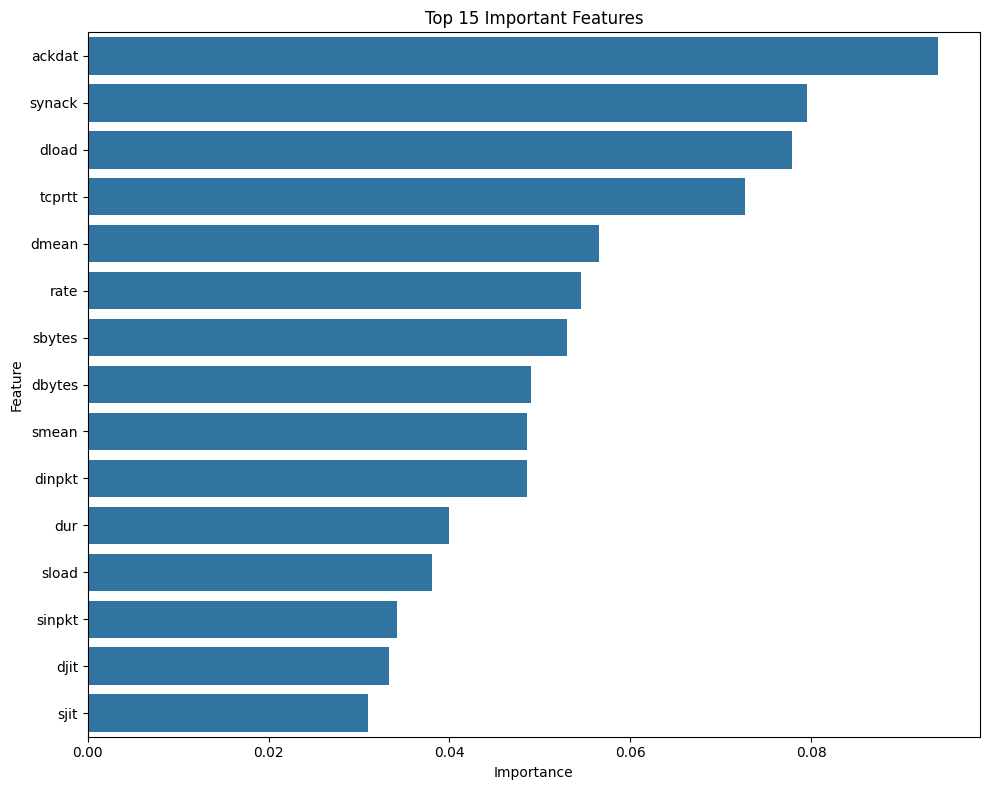

In [10]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.show()

## Select Important Features

In [11]:
selected_features = feature_importance.head(15)["Feature"].tolist()

print(selected_features)

['ackdat', 'synack', 'dload', 'tcprtt', 'dmean', 'rate', 'sbytes', 'dbytes', 'smean', 'dinpkt', 'dur', 'sload', 'sinpkt', 'djit', 'sjit']


## Create Final Dataset

In [12]:
final_data = data_fe[selected_features + ['label', 'attack_cat']]

final_data.head()

,ackdat,synack,dload,tcprtt,dmean,rate,sbytes,dbytes,smean,dinpkt,dur,sload,sinpkt,djit,sjit,label,attack_cat
0,-0.682211,-0.599759,-0.367413,-0.692397,-0.537041,-0.242915,-0.061763,-0.129779,-0.528779,-0.096566,-0.237501,-0.183584,-0.089948,-0.178936,-0.136807,0,6
1,-0.682211,-0.599759,-0.208811,-0.692397,2.924532,-0.242862,-0.059690,0.089099,-0.493230,-0.090415,-0.138246,-0.183615,-0.083601,0.120559,-0.136103,0,6
2,0.244910,0.339636,-0.350616,0.322327,2.006222,-0.243648,-0.061301,-0.061702,-0.516930,-0.014325,0.044557,-0.183651,-0.038524,2.304421,0.249938,0,6
3,-0.682211,-0.599759,-0.369059,-0.692397,-0.468656,-0.243655,-0.060151,-0.126651,-0.493230,-0.025221,0.055547,-0.183645,-0.058094,0.905024,-0.131645,0,6
4,0.369810,0.487734,-0.368857,0.471810,-0.530528,-0.243413,-0.060561,-0.129277,-0.489280,-0.037925,-0.175897,-0.183614,-0.084137,-0.156304,-0.083007,0,6


## Save Engineered Dataset

In [13]:
final_data.to_csv(
    "../output/engineered_dataset.csv",
    index=False
)

print("Engineered dataset saved successfully.")

Engineered dataset saved successfully.
